# 03 Energy mix and decoupling

This is where the analysis proper starts. Two questions:

1. **How have countries changed the way they get their energy?** In particular, who moved away from coal, and what did they replace it with?
2. **Which countries grew their economies while cutting emissions?** And is that a real long-term shift, or partly an accident of history?

Everything here uses the analysis sample saved in notebook 02: 143 countries, 1990 to 2022, with three-year averages at the start and end of each period.

In [1]:
# --- Setup ---
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "requirements.txt").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from src.config import DATA_RAW, DATA_PROCESSED, FIGURES, TABLES, START_YEAR, END_YEAR, AVG_WINDOW
from src.sample import endpoint_means, classify_period
from src.plotting import (set_style, ENERGY_COLOURS, DECOUPLING_ORDER, DECOUPLING_COLOURS,
                          BLUE, AQUA, MAGENTA, GREY, INK_SOFT)

set_style()
pd.set_option("display.width", 120)

sample = pd.read_parquet(DATA_PROCESSED / "analysis_panel.parquet")
print(f"Analysis sample: {sample['country'].nunique()} countries, {START_YEAR}-{END_YEAR}")

Analysis sample: 143 countries, 1990-2022


---
# Part A: The energy mix

## A1. How much energy-mix data do we have?

Before comparing energy mixes, I need to know how many countries actually have the breakdown by source. The emissions and GDP data cover every country in the sample, but the source-by-source energy shares come from a narrower dataset.

In [2]:
# Group the detailed sources into five, so charts stay readable.
SOURCES = {
    "Coal": "coal_share_energy",
    "Oil": "oil_share_energy",
    "Gas": "gas_share_energy",
    "Nuclear": "nuclear_share_energy",
    "Renewables": "renewables_share_energy",   # hydro + wind + solar + other renewables
}
mix_cols = list(SOURCES.values())

has_full_mix = sample.groupby("country")[mix_cols].apply(lambda d: d.notna().all().all())
mix_countries = has_full_mix[has_full_mix].index

print(f"Countries with a full energy mix for {START_YEAR}-{END_YEAR}: {len(mix_countries)} of {sample['country'].nunique()}")

latest = sample[sample["year"] == END_YEAR].set_index("country")
share = latest.loc[mix_countries, "co2"].sum() / latest["co2"].sum() * 100
print(f"Share of the sample's {END_YEAR} emissions they cover: {share:.0f}%")

Countries with a full energy mix for 1990-2022: 76 of 143
Share of the sample's 2022 emissions they cover: 97%


Only about half the countries have a detailed energy mix, but they include every major economy and cover 97% of the sample's emissions. So the energy-mix findings are solid for the countries that matter most for the global total. They say less about smaller, lower-income economies, which is worth a line in the limitations.

## A2. How has the world's energy mix changed?

A starting point for everything else: the global picture.

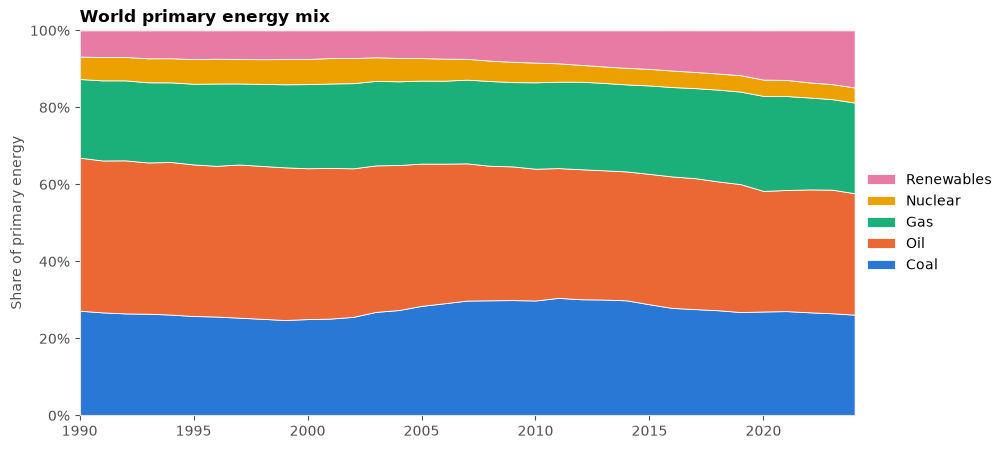

,Coal,Oil,Gas,Nuclear,Renewables
year,,,,,
1990,27.2,39.8,20.4,5.8,6.8
2022,26.8,31.9,23.9,3.9,13.5
2024,26.2,31.5,23.6,3.9,14.8


In [3]:
energy_raw = pd.read_csv(DATA_RAW / "owid-energy-data.csv")
world_mix = (energy_raw[energy_raw["country"] == "World"]
             .set_index("year")[mix_cols]
             .rename(columns={v: k for k, v in SOURCES.items()})
             .loc[START_YEAR:]
             .dropna())

fig, ax = plt.subplots()
ax.stackplot(world_mix.index, world_mix.T.values, labels=world_mix.columns,
             colors=[ENERGY_COLOURS[s] for s in world_mix.columns],
             edgecolor="white", linewidth=0.6)
ax.set_ylim(0, 100)
ax.set_xlim(world_mix.index.min(), world_mix.index.max())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("World primary energy mix")
ax.set_ylabel("Share of primary energy")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc="center left", bbox_to_anchor=(1, 0.5))
fig.savefig(FIGURES / "03_world_energy_mix.png")
plt.show()

world_mix.loc[[START_YEAR, END_YEAR, world_mix.index.max()]].round(1)

The global mix has moved surprisingly little. Fossil fuels supplied about 87% of the world's primary energy in 1990 and still supplied about 83% in 2022. Renewables roughly doubled their share, but coal's share barely changed at all (27% then, 27% now), because falls in Europe and North America were matched by growth in Asia. This matters as context: the country-level shifts below are real, but they haven't yet transformed the global picture.

## A3. Who moved away from coal the most?

Coal is the most carbon-intensive fuel, so the change in its share is a good first measure of transition. I compare the average share in 1990 to 1992 with 2020 to 2022.

In [4]:
mix_sample = sample[sample["country"].isin(mix_countries)]
mix_ends = endpoint_means(mix_sample, mix_cols)

mix_change = pd.DataFrame({
    name: mix_ends[f"{col}_end"] - mix_ends[f"{col}_start"] for name, col in SOURCES.items()
}).round(1)
mix_change["Low-carbon"] = mix_change["Nuclear"] + mix_change["Renewables"]

biggest_coal_cuts = mix_change.sort_values("Coal").head(12)
biggest_coal_cuts

,Coal,Oil,Gas,Nuclear,Renewables,Low-carbon
country,,,,,,
Poland,-33.8,16.7,9.3,0.0,7.8,7.8
Denmark,-31.7,-5.2,0.4,0.0,36.6,36.6
Czechia,-29.5,6.6,6.1,10.0,6.8,16.8
Hong Kong,-28.4,7.7,19.9,0.0,0.7,0.7
United Kingdom,-26.1,-4.5,14.5,-1.8,17.9,16.1
Ireland,-25.4,-3.0,10.8,0.0,17.6,17.6
Greece,-25.0,-12.6,21.6,0.0,16.0,16.0
North Macedonia,-21.8,3.2,11.8,0.0,6.8,6.8
China,-21.2,2.3,6.6,2.3,10.0,12.3


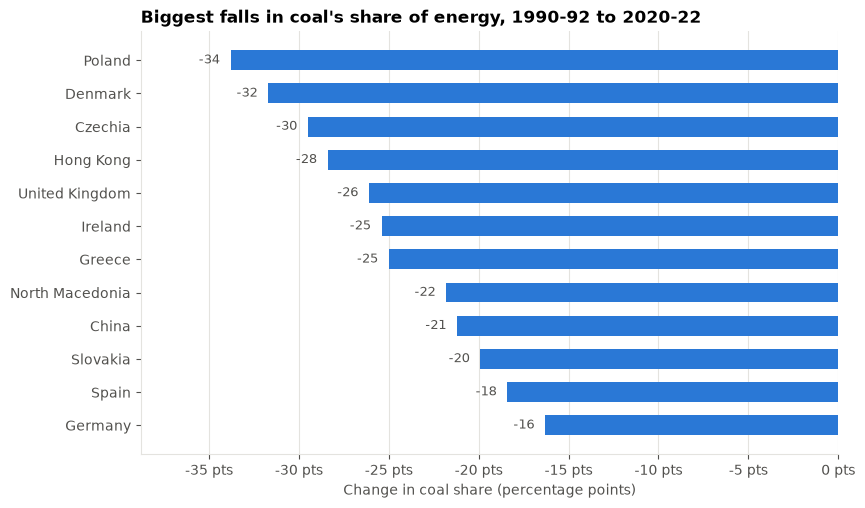

In [5]:
top = biggest_coal_cuts.sort_values("Coal", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top.index, top["Coal"], color=ENERGY_COLOURS["Coal"], height=0.6)
for y, v in enumerate(top["Coal"]):
    ax.text(v - 0.6, y, f"{v:.0f}", va="center", ha="right", fontsize=9, color=INK_SOFT)
ax.set_xlim(top["Coal"].min() - 5, 0)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f} pts"))
ax.grid(axis="y", visible=False)
ax.set_title("Biggest falls in coal's share of energy, 1990-92 to 2020-22")
ax.set_xlabel("Change in coal share (percentage points)")
fig.savefig(FIGURES / "03_coal_share_falls.png")
plt.show()

The biggest shifts are concentrated in Europe, with Poland, Denmark, Czechia and the UK all cutting coal's share by more than 25 points. China also appears, which surprises some people: China still burns more coal than any other country, but its energy use grew so fast that coal's *share* fell even as the amount rose. A share and an absolute amount can tell very different stories.

## A4. What replaced coal?

Cutting coal is only half the story. Switching to gas lowers emissions, but gas is still a fossil fuel. Switching to nuclear or renewables takes the carbon out altogether. This chart splits the change for the same countries.

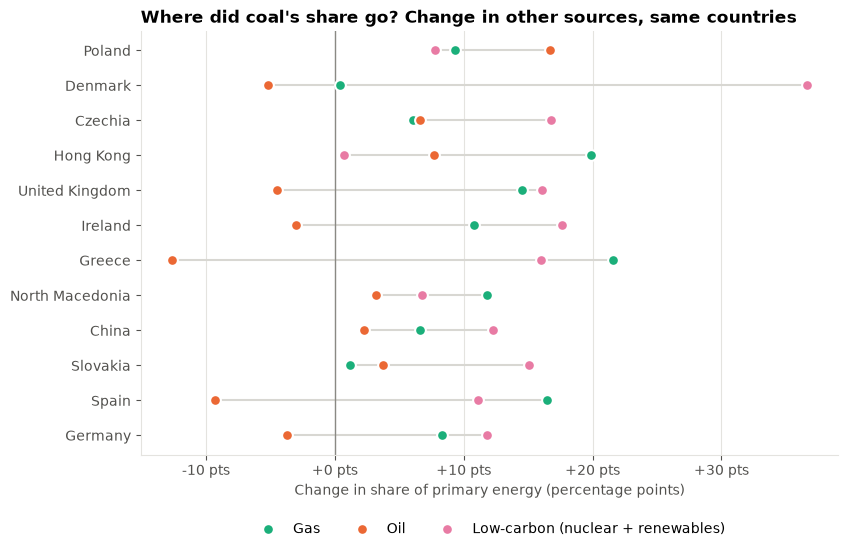

In [6]:
replace = top[["Gas", "Oil", "Low-carbon"]]

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(replace))
ax.axvline(0, color=GREY, linewidth=1)
ax.hlines(y, replace.min(axis=1), replace.max(axis=1), color="#d8d7d2", linewidth=1.5, zorder=1)
ax.scatter(replace["Gas"], y, color=ENERGY_COLOURS["Gas"], s=60, label="Gas", zorder=3, edgecolor="white", linewidth=1.5)
ax.scatter(replace["Oil"], y, color=ENERGY_COLOURS["Oil"], s=60, label="Oil", zorder=3, edgecolor="white", linewidth=1.5)
ax.scatter(replace["Low-carbon"], y, color=ENERGY_COLOURS["Renewables"], s=60, label="Low-carbon (nuclear + renewables)", zorder=3, edgecolor="white", linewidth=1.5)
ax.set_yticks(y, replace.index)
ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:+.0f} pts"))
ax.set_title("Where did coal's share go? Change in other sources, same countries")
ax.set_xlabel("Change in share of primary energy (percentage points)")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.13))
fig.savefig(FIGURES / "03_what_replaced_coal.png")
plt.show()

In [7]:
# Which replacement was bigger in each country?
replace_summary = replace.assign(main_replacement=np.where(replace["Gas"] > replace["Low-carbon"], "Gas", "Low-carbon"))
replace_summary["main_replacement"].value_counts()

main_replacement
Low-carbon    7
Gas           5
Name: count, dtype: int64

The coal-cutters split into two groups. Hong Kong, Greece, Spain and North Macedonia replaced coal mainly with gas. Denmark, the UK, Ireland and Germany moved mainly into renewables, and Czechia leaned on nuclear. Poland is the odd one out: oil gained the most share there, so its mix shifted between fossil fuels more than it moved away from them.

This distinction is the reason the Kaya decomposition in notebook 04 matters. Swapping coal for gas and swapping it for wind both show up as "cleaner energy", and the decomposition will measure how much each country's emissions changed because of that.

## A5. Who grew low-carbon energy the most?

In [8]:
mix_change.sort_values("Low-carbon", ascending=False).head(10)[["Low-carbon", "Nuclear", "Renewables", "Coal", "Gas"]]

,Low-carbon,Nuclear,Renewables,Coal,Gas
country,,,,,
Denmark,36.6,0.0,36.6,-31.7,0.4
Ukraine,20.7,15.6,5.1,-4.8,-8.0
Finland,20.5,2.4,18.1,-7.8,-2.6
Romania,19.9,7.5,12.4,-8.7,-15.7
Portugal,19.1,0.0,19.1,-15.4,22.3
Ireland,17.6,0.0,17.6,-25.4,10.8
Czechia,16.8,10.0,6.8,-29.5,6.1
United Kingdom,16.1,-1.8,17.9,-26.1,14.5
Bulgaria,16.0,5.9,10.1,-4.9,-5.7


Denmark stands well ahead, with low-carbon sources gaining about 37 points of its energy mix, all of it from renewables. Ukraine is second, but for a less positive reason: its total energy use fell by about 70% after 1990, so its existing nuclear plants became a much bigger share of a much smaller total. It's a reminder that a rising share doesn't always mean new clean capacity.

---
# Part B: Decoupling

## B1. The definitions

Decoupling means the link between economic growth and emissions has weakened. There are two levels:

- **Absolute decoupling:** GDP went up and emissions went down. This is the one that matters for climate targets.
- **Relative decoupling:** both went up, but emissions grew more slowly than GDP. Each unit of output is cleaner, but total emissions still rose.
- **None:** emissions grew as fast as the economy, or faster.
- **GDP fell:** the economy shrank, so the question doesn't really apply. Any fall in emissions here is more likely a side effect of the downturn.

## B2. Classifying every country, 1990 to 2022

In [9]:
full = classify_period(sample, START_YEAR, END_YEAR)
counts = full["decoupling"].value_counts().reindex(DECOUPLING_ORDER)
pd.DataFrame({"countries": counts, "share_%": (counts / counts.sum() * 100).round(0)})

,countries,share_%
decoupling,,
Absolute,34,24.0
Relative,69,48.0
None,36,25.0
GDP fell,4,3.0


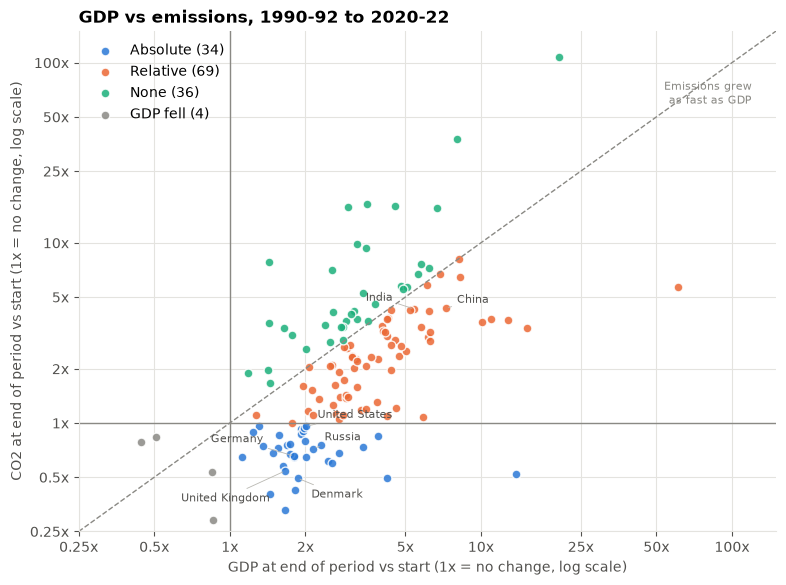

In [10]:
# Plot growth as a multiple: 1x = no change, 2x = doubled, 0.5x = halved.
# A log scale fits everyone, from countries that halved emissions to
# Equatorial Guinea, whose emissions grew over 100-fold with its oil industry.
fig, ax = plt.subplots(figsize=(9, 6.5))

for label in DECOUPLING_ORDER:
    d = full[full["decoupling"] == label]
    ax.scatter(1 + d["gdp_growth"], 1 + d["co2_growth"], s=40, alpha=0.85,
               color=DECOUPLING_COLOURS[label], label=f"{label} ({len(d)})",
               edgecolor="white", linewidth=1)

lim = (0.25, 150)
ax.plot(lim, lim, color=GREY, linestyle="--", linewidth=1)
ax.axhline(1, color=GREY, linewidth=1)
ax.axvline(1, color=GREY, linewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*lim)
ax.set_ylim(*lim)
ticks = [0.25, 0.5, 1, 2, 5, 10, 25, 50, 100]
fmt = mtick.FuncFormatter(lambda x, _: f"{x:g}x")
for axis in (ax.xaxis, ax.yaxis):
    axis.set_major_locator(mtick.FixedLocator(ticks))
    axis.set_major_formatter(fmt)
    axis.set_minor_locator(mtick.NullLocator())

# Label a few well-known countries (offsets in points keep labels apart)
labels = {"United Kingdom": (-75, -22), "Germany": (-60, 10), "Denmark": (10, -14),
          "United States": (8, 6), "Russia": (8, 6), "China": (8, 4), "India": (-35, 6)}
for name, offset in labels.items():
    x, y = 1 + full.loc[name, ["gdp_growth", "co2_growth"]]
    ax.annotate(name, (x, y), fontsize=8, color=INK_SOFT, xytext=offset, textcoords="offset points",
                arrowprops=dict(arrowstyle="-", color="#b9b8b2", linewidth=0.6))

ax.text(120, 80, "Emissions grew\nas fast as GDP", fontsize=8, color=GREY, ha="right", va="top")
ax.set_title(f"GDP vs emissions, {START_YEAR}-92 to {END_YEAR - 2}-{str(END_YEAR)[2:]}")
ax.set_xlabel("GDP at end of period vs start (1x = no change, log scale)")
ax.set_ylabel("CO2 at end of period vs start (1x = no change, log scale)")
ax.legend(loc="upper left")
fig.savefig(FIGURES / "03_decoupling_scatter.png")
plt.show()

Reading the chart: every country **below the dashed line** grew its emissions more slowly than its economy (at least relative decoupling). Countries **below the solid horizontal line (1x) and to the right of the vertical one** grew their economies while cutting emissions (absolute decoupling).

Most of the world sits below the dashed line, so the typical country now produces less CO2 per unit of GDP than it did in 1990. But only about a quarter of countries have actually cut emissions in absolute terms.

## B3. Is decoupling a rich-country story?

To check, I split countries into four equal groups by GDP per person at the end of the period.

In [11]:
ends = endpoint_means(sample, ["gdp", "population"])
gdp_pc = ends["gdp_end"] / ends["population_end"]
full["income_group"] = pd.qcut(gdp_pc, 4, labels=["Lowest", "Lower-middle", "Upper-middle", "Highest"])

by_income = pd.crosstab(full["income_group"], full["decoupling"])[DECOUPLING_ORDER]
by_income

decoupling,Absolute,Relative,None,GDP fell
income_group,,,,
Lowest,1,10,23,2
Lower-middle,2,21,11,2
Upper-middle,10,23,2,0
Highest,21,15,0,0


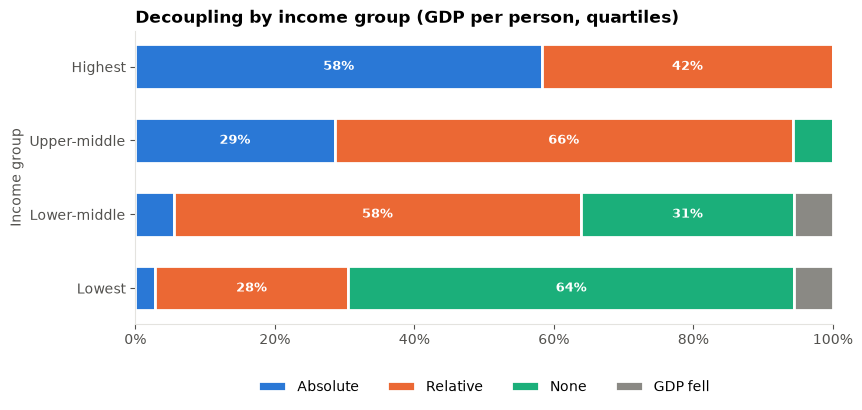

In [12]:
shares = by_income.div(by_income.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 3.8))
left = np.zeros(len(shares))
for label in DECOUPLING_ORDER:
    ax.barh(shares.index.astype(str), shares[label], left=left, color=DECOUPLING_COLOURS[label],
            label=label, height=0.6, edgecolor="white", linewidth=2)
    for i, v in enumerate(shares[label]):
        if v >= 8:
            ax.text(left[i] + v / 2, i, f"{v:.0f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    left += shares[label].values
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(False)
ax.set_title("Decoupling by income group (GDP per person, quartiles)")
ax.set_ylabel("Income group")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.15))
fig.savefig(FIGURES / "03_decoupling_by_income.png")
plt.show()

Yes, strongly. Most of the richest quarter of countries have absolutely decoupled, against almost none of the poorest quarter. That's not surprising. Poorer countries are still building the energy systems that richer countries built decades ago, and their emissions per person start from a very low base. It does mean "decoupling" as a success story mostly describes wealthy economies.

## B4. Did the early 1990s flatter some countries?

Looking at the list of absolute decouplers, a lot of them are former Soviet or Eastern Bloc countries. That raises an obvious question. Their economies, and their heavy industry, collapsed in the early 1990s, so their emissions fell sharply before any climate policy existed. Is their "decoupling" just the aftermath of that collapse?

To test this, I split the period in two and classify each half separately:
- **Early:** 1990 to 2005
- **Recent:** 2005 to 2022

A country that decoupled in the recent period too is showing a sustained shift, not a one-off.

In [13]:
SPLIT_YEAR = 2005

early = classify_period(sample, START_YEAR, SPLIT_YEAR)
recent = classify_period(sample, SPLIT_YEAR, END_YEAR)

periods = pd.DataFrame({
    "full": full["decoupling"],
    "early": early["decoupling"],
    "recent": recent["decoupling"],
})

pd.DataFrame({
    f"Early ({START_YEAR}-{SPLIT_YEAR})": early["decoupling"].value_counts(),
    f"Recent ({SPLIT_YEAR}-{END_YEAR})": recent["decoupling"].value_counts(),
}).reindex(DECOUPLING_ORDER)

,Early (1990-2005),Recent (2005-2022)
decoupling,,
Absolute,28,40
Relative,69,55
None,38,36
GDP fell,8,12


In [14]:
# Absolute decouplers over the full period that did NOT absolutely decouple recently
not_sustained = periods[(periods["full"] == "Absolute") & (periods["recent"] != "Absolute")]
not_sustained

,full,early,recent
country,,,
Azerbaijan,Absolute,Absolute,Relative
Greece,Absolute,Relative,GDP fell
Italy,Absolute,Relative,GDP fell
Jamaica,Absolute,None,GDP fell
Kuwait,Absolute,Absolute,Relative
Russia,Absolute,Absolute,Relative
Zimbabwe,Absolute,GDP fell,Relative


In [15]:
# Countries that only started absolutely decoupling in the recent period
newcomers = periods[(periods["recent"] == "Absolute") & (periods["early"] != "Absolute")]
print(f"{len(newcomers)} countries became absolute decouplers after {SPLIT_YEAR}:\n")
print(", ".join(sorted(newcomers.index)))

23 countries became absolute decouplers after 2005:

Australia, Austria, Belgium, Canada, Croatia, Cyprus, Eswatini, Finland, France, Hong Kong, Ireland, Israel, Japan, Mexico, Netherlands, New Zealand, Norway, Portugal, Slovenia, South Africa, Spain, United States, Uzbekistan


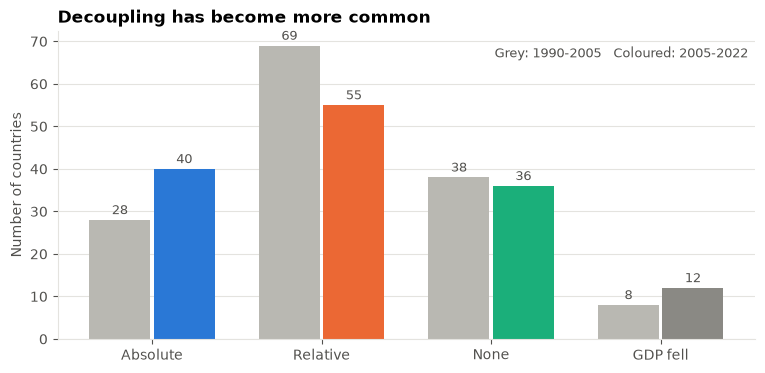

In [16]:
# Chart: how many countries were in each category, early vs recent
compare = pd.DataFrame({
    f"{START_YEAR}-{SPLIT_YEAR}": early["decoupling"].value_counts(),
    f"{SPLIT_YEAR}-{END_YEAR}": recent["decoupling"].value_counts(),
}).reindex(DECOUPLING_ORDER)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(compare))
w = 0.36
b1 = ax.bar(x - w / 2 - 0.01, compare.iloc[:, 0], w, color="#b9b8b2", label=compare.columns[0])
b2 = ax.bar(x + w / 2 + 0.01, compare.iloc[:, 1], w, color=[DECOUPLING_COLOURS[c] for c in compare.index], label=compare.columns[1])
ax.bar_label(b1, fontsize=9, color=INK_SOFT, padding=2)
ax.bar_label(b2, fontsize=9, color=INK_SOFT, padding=2)
ax.set_xticks(x, compare.index)
ax.grid(axis="x", visible=False)
ax.set_ylabel("Number of countries")
ax.set_title("Decoupling has become more common")
ax.text(0.99, 0.95, f"Grey: {compare.columns[0]}   Coloured: {compare.columns[1]}", transform=ax.transAxes,
        ha="right", va="top", fontsize=9, color=INK_SOFT)
fig.savefig(FIGURES / "03_decoupling_early_vs_recent.png")
plt.show()

Three findings come out of this, and they're the most important in the notebook.

**1. Some decoupling was an accident of history.** Russia, Azerbaijan and Kuwait count as absolute decouplers over the full period, but only because their emissions dropped in the early 1990s (Soviet collapse in two cases, the 1991 oil fires in Kuwait). Since 2005, their emissions have been growing again. Jamaica and Zimbabwe also drop out, both small economies that went through severe downturns.

**2. Some was a recession, not a transition.** Greece and Italy also drop out of the recent absolute group, but for a different reason: their economies are smaller in real terms than in the mid-2000s, after the financial and eurozone crises. Their emissions fell, but so did output.

**3. Decoupling has spread.** Despite those cases, the number of absolute decouplers rose from 28 in the early period to 40 in the recent one. The newcomers include the US, Japan, France, Canada and Australia, large economies that were still growing their emissions in the 1990s. That's the genuinely encouraging result: the countries decoupling now are mostly doing it during growth, not collapse.

## B5. The global picture

Finally, putting all 143 countries together.

In [17]:
totals = endpoint_means(sample, ["gdp", "co2"]).sum()
gdp_growth = totals["gdp_end"] / totals["gdp_start"] - 1
co2_growth = totals["co2_end"] / totals["co2_start"] - 1
intensity_change = (1 + co2_growth) / (1 + gdp_growth) - 1

print(f"Combined GDP growth:               {gdp_growth:+.0%}")
print(f"Combined CO2 growth:               {co2_growth:+.0%}")
print(f"Change in CO2 per unit of GDP:     {intensity_change:+.0%}")

Combined GDP growth:               +184%
Combined CO2 growth:               +60%
Change in CO2 per unit of GDP:     -44%


Taken together, the world has **relatively** decoupled but not **absolutely**. The combined economy nearly tripled while emissions rose by around 60%, so each unit of output produces far less CO2 than in 1990. But total emissions are still going up, and total emissions are what the atmosphere responds to.

## Save the results

In [18]:
out = full.join(early.add_prefix("early_")).join(recent.add_prefix("recent_"))
out = out.drop(columns=["early_gdp_growth", "early_co2_growth", "recent_gdp_growth", "recent_co2_growth"])
out[["gdp_growth", "co2_growth"]] = (out[["gdp_growth", "co2_growth"]] * 100).round(1)
out = out.rename(columns={"gdp_growth": "gdp_growth_pct", "co2_growth": "co2_growth_pct"})
out.to_csv(TABLES / "decoupling_classification.csv")
mix_change.to_csv(TABLES / "energy_mix_change.csv")

print(f"Saved decoupling results for {len(out)} countries")
print(f"Saved energy mix changes for {len(mix_change)} countries")

Saved decoupling results for 143 countries
Saved energy mix changes for 76 countries


## Summary

**Energy mix**
- The global mix has shifted little: fossil fuels still supply over four-fifths of primary energy, and coal's global share is almost unchanged since 1990.
- The biggest moves away from coal were in Europe (Poland, Denmark, Czechia, the UK), with China's coal share also falling as total energy use grew.
- Countries replaced coal in different ways: some mainly with gas, others with renewables or nuclear. Denmark made by far the largest low-carbon shift.

**Decoupling**
- About a quarter of countries grew their economies while cutting emissions between 1990 and 2022, and most of the rest cut emissions per unit of GDP.
- Absolute decoupling is mostly a high-income story.
- A few full-period decouplers owe it to the early-1990s collapse (Russia, Azerbaijan, Kuwait) or to later recessions (Greece, Italy).
- Decoupling has spread: 28 countries absolutely decoupled in 1990 to 2005, rising to 40 in 2005 to 2022, including the US and Japan.
- Globally, emissions per unit of GDP have fallen sharply, but total emissions are still rising.

**Next:** notebook 04 uses the Kaya decomposition to explain *why* emissions changed in each country: population, wealth, energy efficiency or cleaner energy.